In [1]:
import pandas as pd
import os

real_path = ""
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            real_path = os.path.join(dirname, filename)
            print(f"Alamat asli ketemu: {real_path}\n")

if real_path != "":
    df = pd.read_csv(real_path)
    print("Tabel berhasil dipanggil! Ini 5 data teratasnya:")
    display(df.head())
else:
    print("Waduh, file .csv tetap tidak ditemukan di folder Input.")

Alamat asli ketemu: /kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv

Tabel berhasil dipanggil! Ini 5 data teratasnya:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("--- Info Tipe Data ---")
df.info()


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


print("\n--- Jumlah Data Kosong ---")
print(df.isnull().sum())


df.drop('customerID', axis=1, inplace=True)

print("\nCleaning Selesai! customerID dihapus & TotalCharges sudah jadi angka.")

--- Info Tipe Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7

KeyError: "['customerID'] not found in axis"

/tmp/ipykernel_55/1710678604.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette='viridis')


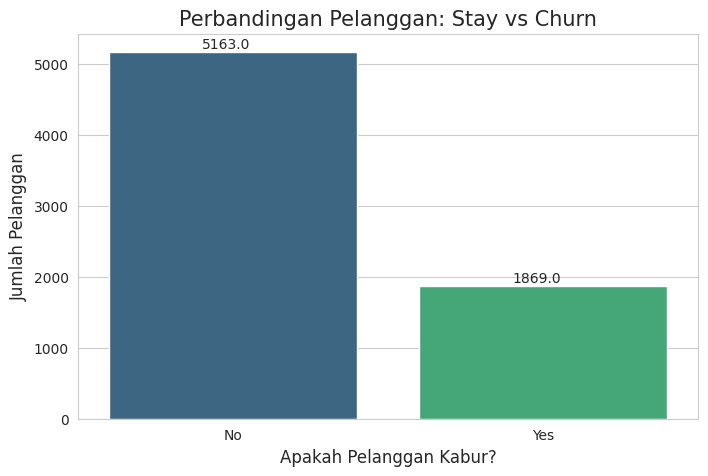

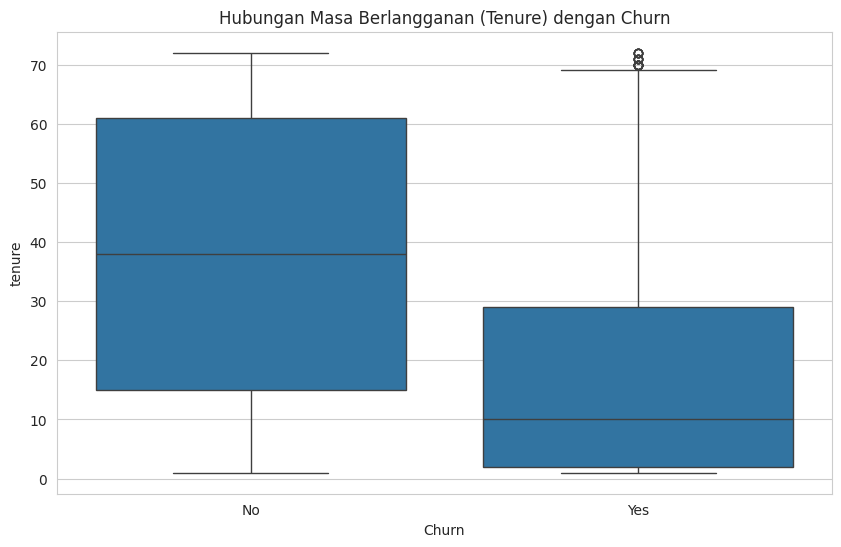

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df.dropna(inplace=True)

sns.set_style('whitegrid')
plt.figure(figsize=(8, 5))

ax = sns.countplot(x='Churn', data=df, palette='viridis')

plt.title('Perbandingan Pelanggan: Stay vs Churn', fontsize=15)
plt.xlabel('Apakah Pelanggan Kabur?', fontsize=12)
plt.ylabel('Jumlah Pelanggan', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.3, p.get_height() + 50))

plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Hubungan Masa Berlangganan (Tenure) dengan Churn')
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(df)

print("Data sekarang sudah jadi angka semua!")
display(df.head())

Data sekarang sudah jadi angka semua!


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,True,False,False,False,True,False,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,True,False,True,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,True,False,False,True,False,False,False,False,True,False


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Akurasi Model: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\n--- Laporan Detail ---")
print(classification_report(y_test, y_pred))

Akurasi Model: 78.54%

--- Laporan Detail ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



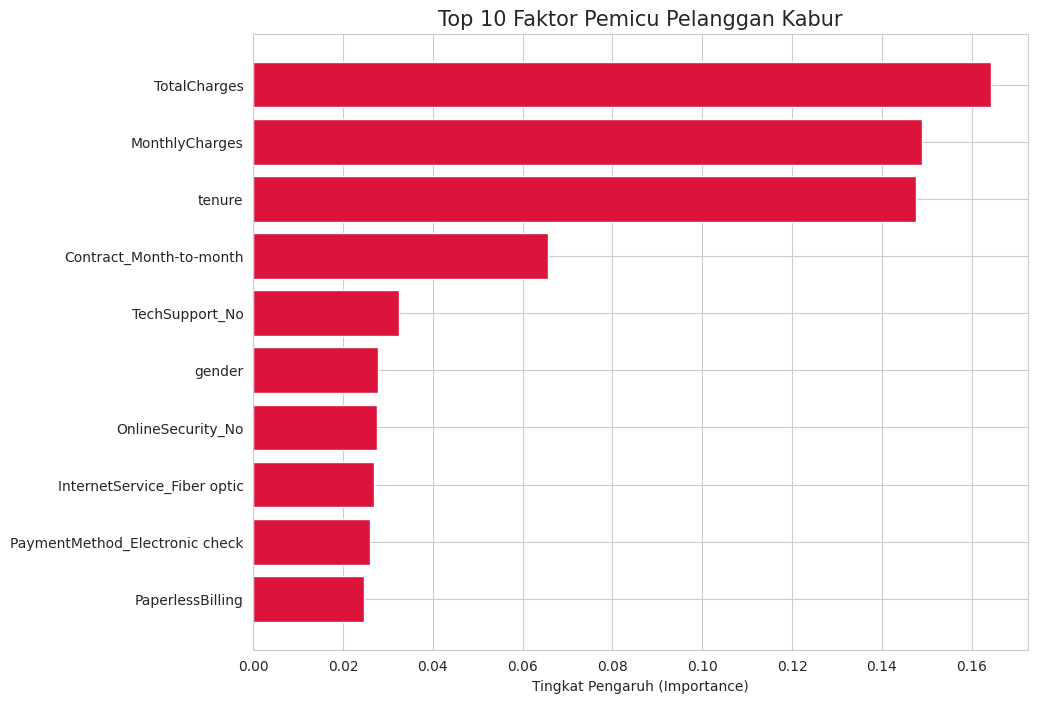

In [7]:
import numpy as np

features = X.columns
importances = model.feature_importances_
indices = np.argsort(importances)[-10:] 

plt.figure(figsize=(10, 8))
plt.title('Top 10 Faktor Pemicu Pelanggan Kabur', fontsize=15)
plt.barh(range(len(indices)), importances[indices], color='crimson', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Tingkat Pengaruh (Importance)')
plt.show()